In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as pit
import seaborn as sns

#plt.style.use('ggplot')
# sns.set(rc={'figure.figsize'(10,5)})

In [10]:
import os 
os.getcwd()

'C:\\Users\\Sirushtika S\\OneDrive\\Desktop\\weekly task'

In [11]:
df = pd.read_csv(r"C:\\Users\\Sirushtika S\\OneDrive\\Desktop\\weekly task\airlines_flights_data.csv")

In [12]:
df.head()

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


# TASK 1 DATA EXPLORATION

In [13]:
# First 5 rows
print(df.head())

# Dataset information
print(df.info())

# Statistical summary
print(df.describe())

# Shape
print("Shape:", df.shape)

# Missing values
print(df.isnull().sum())
 
# Duplicate records
print("Duplicate Rows:", df.duplicated().sum())

# Data types
print(df.dtypes)

   index   airline   flight source_city departure_time stops   arrival_time  \
0      0  SpiceJet  SG-8709       Delhi        Evening  zero          Night   
1      1  SpiceJet  SG-8157       Delhi  Early_Morning  zero        Morning   
2      2   AirAsia   I5-764       Delhi  Early_Morning  zero  Early_Morning   
3      3   Vistara   UK-995       Delhi        Morning  zero      Afternoon   
4      4   Vistara   UK-963       Delhi        Morning  zero        Morning   

  destination_city    class  duration  days_left  price  
0           Mumbai  Economy      2.17          1   5953  
1           Mumbai  Economy      2.33          1   5953  
2           Mumbai  Economy      2.17          1   5956  
3           Mumbai  Economy      2.25          1   5955  
4           Mumbai  Economy      2.33          1   5955  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------       

# TASK 2 UNIVARIATE ANALYSIS

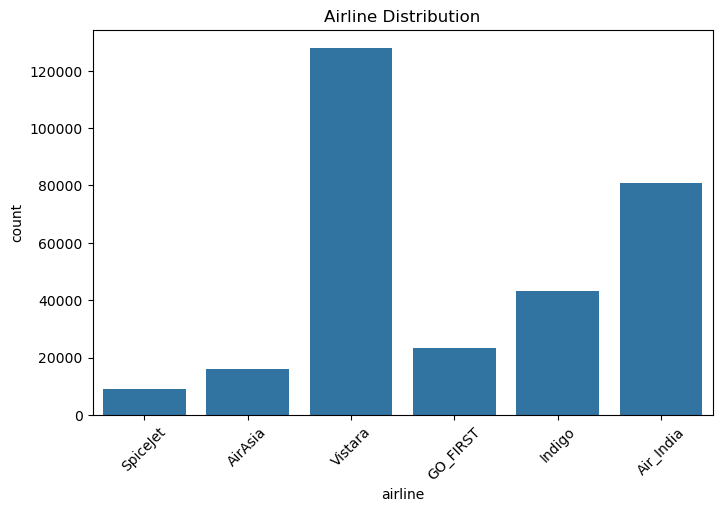

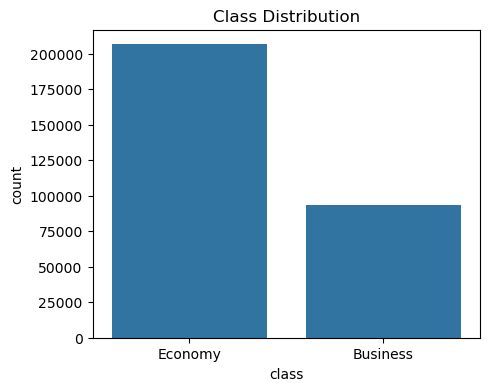

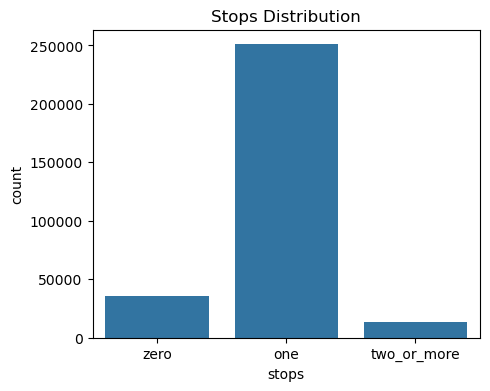

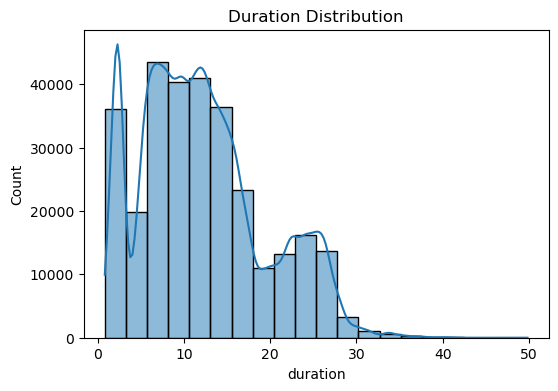

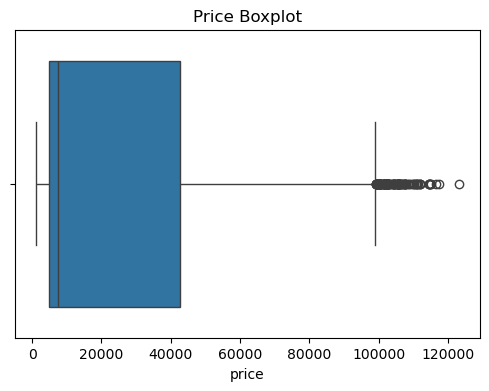

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Airline
plt.figure(figsize=(8,5))
sns.countplot(x='airline', data=df)
plt.xticks(rotation=45)
plt.title("Airline Distribution")
plt.show()

# Class
plt.figure(figsize=(5,4))
sns.countplot(x='class', data=df)
plt.title("Class Distribution")
plt.show()

# Stops
plt.figure(figsize=(5,4))
sns.countplot(x='stops', data=df)
plt.title("Stops Distribution")
plt.show()

# Duration
plt.figure(figsize=(6,4))
sns.histplot(df['duration'], bins=20, kde=True)
plt.title("Duration Distribution")
plt.show()

# Price
plt.figure(figsize=(6,4))
sns.boxplot(x=df['price'])
plt.title("Price Boxplot")
plt.show()

# TASK 3 BIVARIATE ANALYSIS

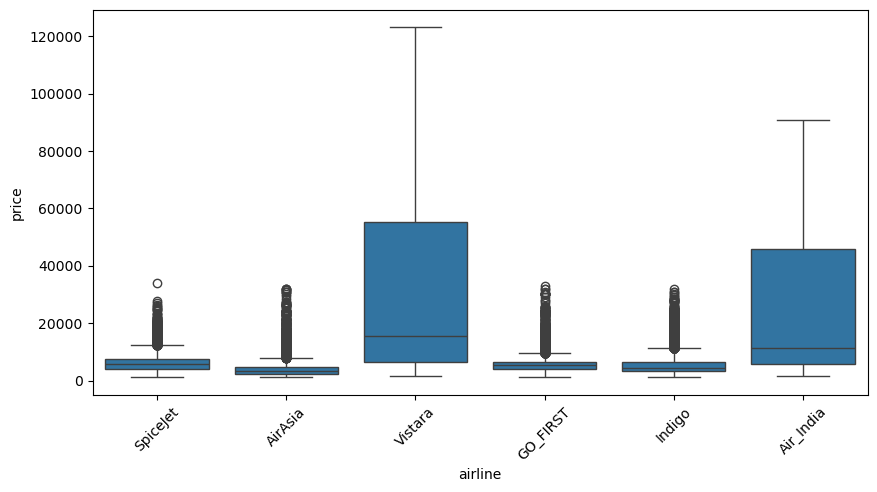

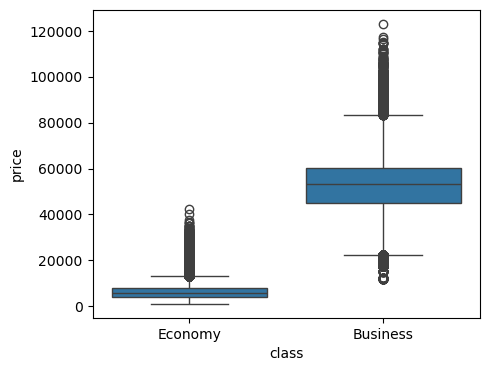

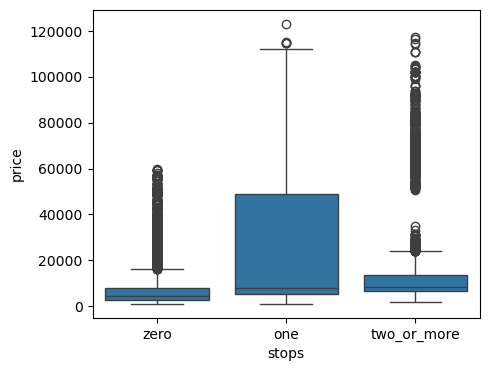

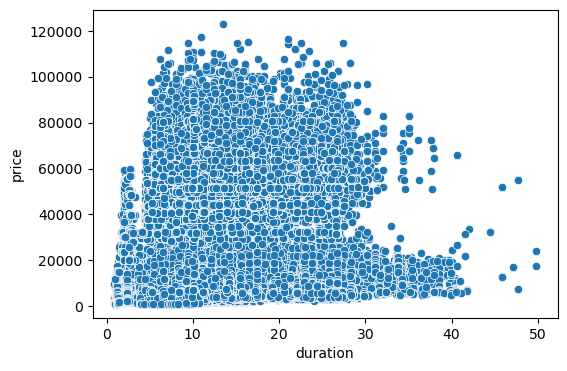

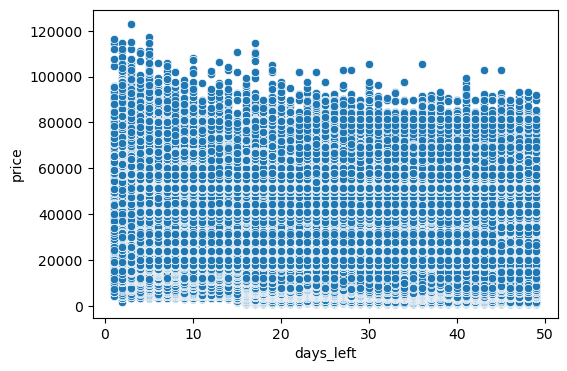

In [15]:
# Airline vs Price
plt.figure(figsize=(10,5))
sns.boxplot(x='airline', y='price', data=df)
plt.xticks(rotation=45)
plt.show()

# Class vs Price
plt.figure(figsize=(5,4))
sns.boxplot(x='class', y='price', data=df)
plt.show()

# Stops vs Price
plt.figure(figsize=(5,4))
sns.boxplot(x='stops', y='price', data=df)
plt.show()

# Duration vs Price
plt.figure(figsize=(6,4))
sns.scatterplot(x='duration', y='price', data=df)
plt.show()

# Days Left vs Price
plt.figure(figsize=(6,4))
sns.scatterplot(x='days_left', y='price', data=df)
plt.show()

# TASK 4 CORRELATION AND FEATURE ENGINEERING

              index   airline     stops     class  duration  days_left  \
index      1.000000  0.179822 -0.123422 -0.802099  0.159007   0.014638   
airline    0.179822  1.000000 -0.029838 -0.178862 -0.001651  -0.010678   
stops     -0.123422 -0.029838  1.000000  0.100262 -0.473860  -0.007047   
class     -0.802099 -0.178862  0.100262  1.000000 -0.138710   0.013039   
duration   0.159007 -0.001651 -0.473860 -0.138710  1.000000  -0.039157   
days_left  0.014638 -0.010678 -0.007047  0.013039 -0.039157   1.000000   
price      0.761177  0.243358 -0.202620 -0.937860  0.204222  -0.091949   

              price  
index      0.761177  
airline    0.243358  
stops     -0.202620  
class     -0.937860  
duration   0.204222  
days_left -0.091949  
price      1.000000  


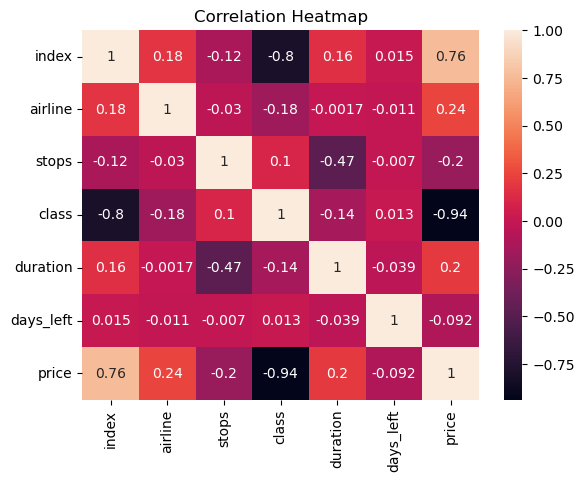

   index  airline   flight source_city departure_time  stops   arrival_time  \
0      0        4  SG-8709       Delhi        Evening      2          Night   
1      1        4  SG-8157       Delhi  Early_Morning      2        Morning   
2      2        0   I5-764       Delhi  Early_Morning      2  Early_Morning   
3      3        5   UK-995       Delhi        Morning      2      Afternoon   
4      4        5   UK-963       Delhi        Morning      2        Morning   

  destination_city  class  duration  days_left  price  price_per_day  \
0           Mumbai      1      2.17          1   5953         2976.5   
1           Mumbai      1      2.33          1   5953         2976.5   
2           Mumbai      1      2.17          1   5956         2978.0   
3           Mumbai      1      2.25          1   5955         2977.5   
4           Mumbai      1      2.33          1   5955         2977.5   

   long_flight  
0        False  
1        False  
2        False  
3        False  
4      

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("airlines_flights_data.csv")

# Encode categorical variables
df["airline"] = df["airline"].astype("category").cat.codes
df["class"] = df["class"].astype("category").cat.codes
df["stops"] = df["stops"].astype("category").cat.codes

# Select numerical columns
data = df.select_dtypes(include="number")

# Correlation
corr = data.corr()

print(corr)

# Heatmap
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

# Feature 1: Price per day left
df["price_per_day"] = df["price"] / (df["days_left"] + 1)

# Feature 2: Duration category
df["long_flight"] = df["duration"] > df["duration"].mean()

print(df.head())